# F1 Data Exploration

This notebook explores the F1 telemetry data for 2023 races.

In [2]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..'))

import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import load_race_data

# Load data for one race
df = load_race_data(2023, 'Monza')
print(f"Loaded {len(df)} lap records")
print(df.head())

core           INFO 	Loading data for Italian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 06:25.888000 before the recorded end of the session.
core        WARNING 	Driver 11 completed the race distance 06:19.824000 before the recorded end of the session.
core        WAR

Loaded 948 lap records
  Driver                LapTime  LapNumber Compound  TyreLife  Stint  \
0    VER 0 days 00:01:27.905000        1.0   MEDIUM       1.0    1.0   
1    VER 0 days 00:01:26.163000        2.0   MEDIUM       2.0    1.0   
2    VER 0 days 00:01:25.702000        3.0   MEDIUM       3.0    1.0   
3    VER 0 days 00:01:26.050000        4.0   MEDIUM       4.0    1.0   
4    VER 0 days 00:01:26.176000        5.0   MEDIUM       5.0    1.0   

   IsAccurate  
0       False  
1        True  
2        True  
3        True  
4        True  


Basic stats:
                         LapTime   LapNumber    TyreLife       Stint
count                        948  948.000000  948.000000  948.000000
mean   0 days 00:01:27.766147679   25.515823   14.140295    1.725738
std    0 days 00:00:03.598416700   14.510556    8.189695    0.623960
min       0 days 00:01:25.072000    1.000000    1.000000    1.000000
25%       0 days 00:01:26.463250   13.000000    8.000000    1.000000
50%       0 days 00:01:27.044000   25.000000   13.000000    2.000000
75%       0 days 00:01:27.518750   38.000000   19.000000    2.000000
max       0 days 00:01:53.593000   51.000000   39.000000    3.000000
Number of drivers: 19
Compounds used: ['MEDIUM' 'HARD']


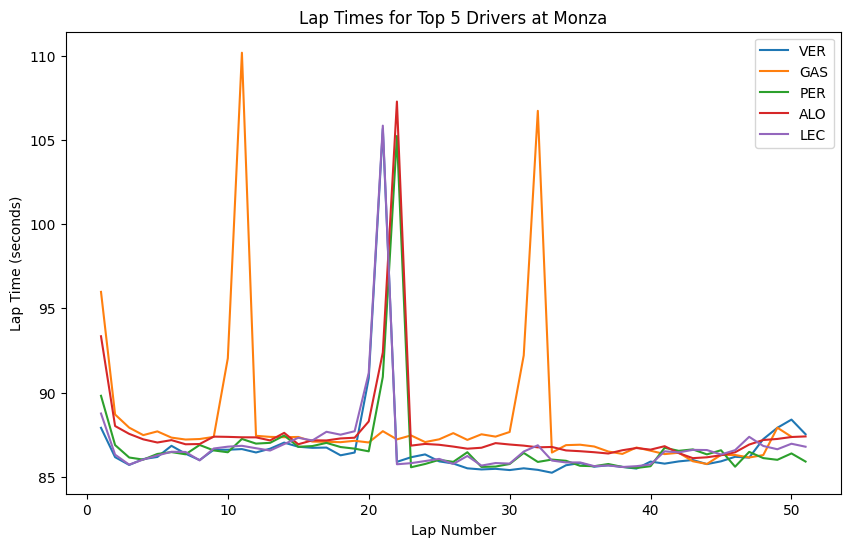

In [3]:
# Basic statistics
print("Basic stats:")
print(df.describe())

# Unique drivers
print(f"Number of drivers: {df['Driver'].nunique()}")
print(f"Compounds used: {df['Compound'].unique()}")

# Plot lap times
plt.figure(figsize=(10, 6))
for driver in df['Driver'].unique()[:5]:  # First 5 drivers
    driver_data = df[df['Driver'] == driver]
    plt.plot(driver_data['LapNumber'], driver_data['LapTime'].dt.total_seconds(), label=driver)
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('Lap Times for Top 5 Drivers at Monza')
plt.legend()
plt.show()